In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import importlib
import experiment_utils

importlib.reload(experiment_utils)

from experiment_utils import (
    MLPClassifier,
    run_one_experiment,
    run,
    save_result
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema_v2.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df["date"] = pd.to_datetime(df["date"], format="mixed")

df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
df.head()

(1239, 49)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,...,away_form_sma7,away_form_ema50,away_form_ema33,away_form_ema25,form_diff_sma3,form_diff_sma5,form_diff_sma7,form_diff_ema50,form_diff_ema33,form_diff_ema25
0,2022-01-27,Jamaica,Mexico,1.0,2.0,FIFA World Cup qualification,Kingston,Jamaica,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-27,United Arab Emirates,Syria,2.0,0.0,FIFA World Cup qualification,Dubai,United Arab Emirates,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-27,Honduras,Canada,0.0,2.0,FIFA World Cup qualification,San Pedro Sula,Honduras,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-27,Costa Rica,Panama,1.0,0.0,FIFA World Cup qualification,San José,Costa Rica,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-27,Lebanon,South Korea,0.0,1.0,FIFA World Cup qualification,Sidon,Lebanon,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
features = [
    "form_diff_ema25"
]

target = "result"

In [4]:
print("Broj redova pre uklanjanja NaN vrednosti:", len(df))
print()
print("NaN vrednosti u feature kolonama:")
print(df[features].isna().sum())

df = df.dropna(subset=features + [target]).reset_index(drop=True)

print()
print("Broj redova posle uklanjanja NaN vrednosti:", len(df))
print()
print("Provera NaN vrednosti posle filtriranja:")
print(df[features].isna().sum())

df[features + [target]].head()

Broj redova pre uklanjanja NaN vrednosti: 1239

NaN vrednosti u feature kolonama:
form_diff_ema25    129
dtype: int64

Broj redova posle uklanjanja NaN vrednosti: 1110

Provera NaN vrednosti posle filtriranja:
form_diff_ema25    0
dtype: int64


,form_diff_ema25,result
0,0.0,0
1,0.0,1
2,0.0,-1
3,0.0,1
4,0.0,1


In [5]:
X = df[features].values

label_map = {
    -1: 0,   # away win
     0: 1,   # draw
     1: 2    # home win
}

y = df[target].map(label_map).values

print("Label mapping:")
print("-1 -> 0  away win")
print(" 0 -> 1  draw")
print(" 1 -> 2  home win")

Label mapping:
-1 -> 0  away win
 0 -> 1  draw
 1 -> 2  home win


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (888, 1)
X_test: (222, 1)
y_train: (888,)
y_test: (222,)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("Tensor shapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

Tensor shapes:
X_train_tensor: torch.Size([888, 1])
y_train_tensor: torch.Size([888])
X_test_tensor: torch.Size([222, 1])
y_test_tensor: torch.Size([222])


In [9]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 1.0233 | val loss = 0.9765 | val acc = 0.5843
Epoch 100/1000 | train loss = 1.0217 | val loss = 0.9842 | val acc = 0.5787
Epoch 150/1000 | train loss = 1.0190 | val loss = 0.9826 | val acc = 0.5843
Epoch 200/1000 | train loss = 1.0142 | val loss = 0.9833 | val acc = 0.5787
Epoch 250/1000 | train loss = 1.0155 | val loss = 0.9818 | val acc = 0.5730
Epoch 300/1000 | train loss = 1.0174 | val loss = 0.9842 | val acc = 0.5730
Epoch 350/1000 | train loss = 1.0158 | val loss = 0.9856 | val acc = 0.5730
Epoch 400/1000 | train loss = 1.0159 | val loss = 0.9837 | val acc = 0.5730
Epoch 450/1000 | train loss = 1.0156 | val loss = 0.9867 | val acc = 0.5787
Epoch 500/1000 | train loss = 1.0188 | val loss = 0.9876 | val acc = 0.5787
Epoch 550/1000 | train loss = 1.0146 | val loss = 0.9832 | val acc = 0.5787
Epoch 600/1000 | train loss = 1.0140 | val loss = 0.9831 | val acc = 0.5787
Epoch 650/1000 | train loss = 1.0212 | val loss = 0.9892 | val acc = 0.5730
Epoch 700/100

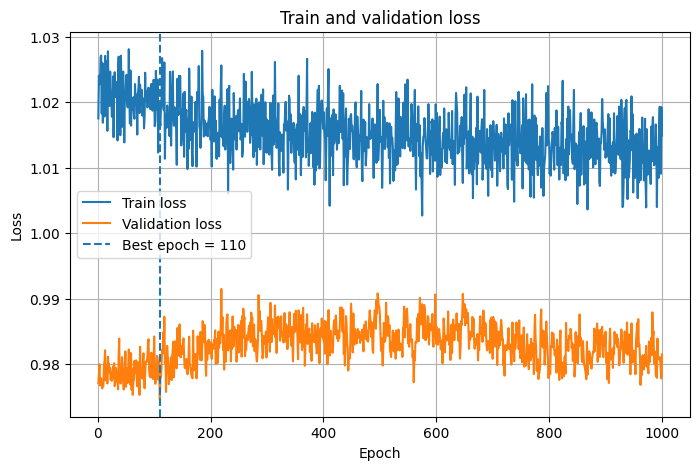

0.6081081081081081

In [11]:
run_one_experiment(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    batch_size=16,
    num_epochs=1000,
    seed=42,
    validation_fraction=0.2,
    plot_graph=True,
    verbose=True
)

In [12]:
best_num_epochs = 110

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_runs=10,
    num_epochs=best_num_epochs,
    batch_size=16,
    learning_rate=0.001
)

Run 1/10
Accuracy: 0.6081 | Precision: 0.3987 | Recall: 0.4951 | Specificity: 0.7675 | F1: 0.4405

Run 2/10
Accuracy: 0.6126 | Precision: 0.4065 | Recall: 0.4918 | Specificity: 0.7654 | F1: 0.4408

Run 3/10
Accuracy: 0.6081 | Precision: 0.3988 | Recall: 0.4930 | Specificity: 0.7667 | F1: 0.4393

Run 4/10
Accuracy: 0.6081 | Precision: 0.4002 | Recall: 0.4930 | Specificity: 0.7658 | F1: 0.4398

Run 5/10
Accuracy: 0.6081 | Precision: 0.3988 | Recall: 0.4930 | Specificity: 0.7667 | F1: 0.4393

Run 6/10
Accuracy: 0.6081 | Precision: 0.4002 | Recall: 0.4930 | Specificity: 0.7658 | F1: 0.4398

Run 7/10
Accuracy: 0.6081 | Precision: 0.3988 | Recall: 0.4930 | Specificity: 0.7667 | F1: 0.4393

Run 8/10
Accuracy: 0.6126 | Precision: 0.4022 | Recall: 0.4981 | Specificity: 0.7696 | F1: 0.4436

Run 9/10
Accuracy: 0.6216 | Precision: 0.4087 | Recall: 0.5105 | Specificity: 0.7764 | F1: 0.4534

Run 10/10
Accuracy: 0.6081 | Precision: 0.3987 | Recall: 0.4951 | Specificity: 0.7675 | F1: 0.4405

Summary o

In [13]:
save_result(
    experiment_name="Experiment_2-12_v2_points_EMA25_Diff",
    summary=summary
)


Saved result for Experiment_2-12_v2_points_EMA25_Diff
File: ../results/experiment_summary_final.csv
